生成内部点数: 1623
生成边界点数: 100
Patch 数量: 22
预测点数: 1623


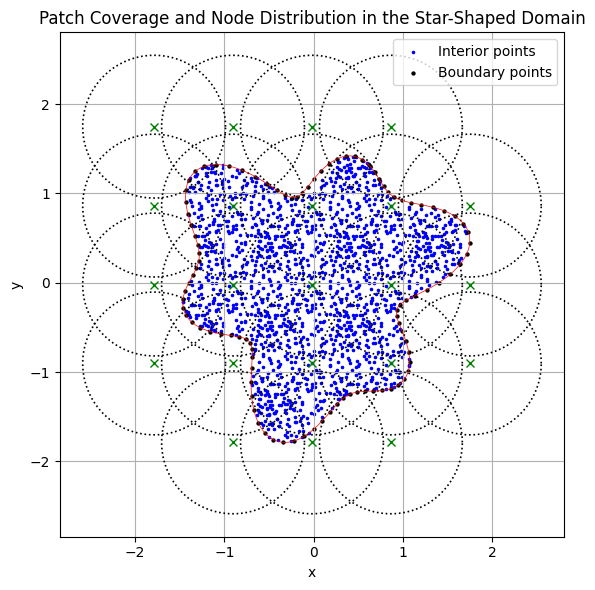

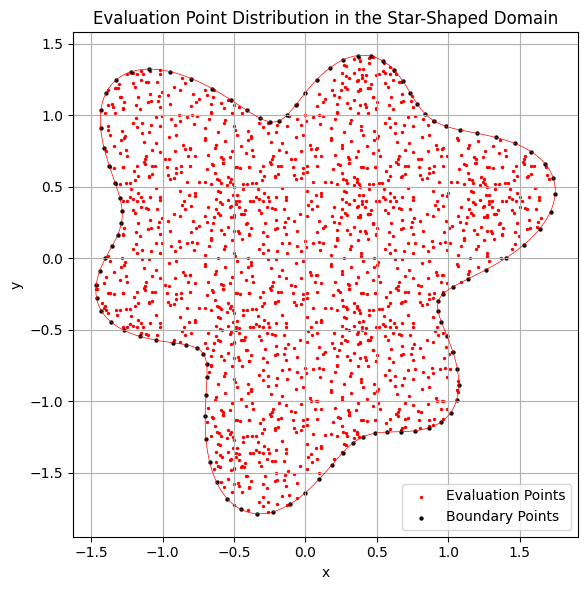

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()

    plt.show()


# ============================
# Example usage
# ============================
if __name__ == "__main__":
    # parameters (same defaults as your MATLAB example)
    N_patch_grid = 5
    N_local_per_patch = 200
    N_boundary = 100
    R_ptch = 0.8
    mode = "c-rbf-pum"  # or "ls-rbf-pum"

    X_inner, X_boundary, ptch, grid_eval, boundary_curve = generator_points_star(
        N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode
    )

    print("生成内部点数:", X_inner.shape[0])
    print("生成边界点数:", X_boundary.shape[0])
    print("Patch 数量:", ptch['C'].shape[0])
    print("预测点数:", grid_eval.shape[0])

    # 绘图
    plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve)

X.shape: (1823, 2)

--- iter 0 ---
========== Patch report ==========
num patches: 40
R = 0.4559914057467497
uncovered X: 0 / 1823
cover count min/mean/max: 1 2.290729566648382 4
patch nX min/mean/max: 2 104.4 180
H = 0.5373910252771885
target_n = 100
mean nX & target_n = 104.4 & 100
fill_distance of X: 0.07872309159537244
Time to construct L and LI: 3.482309341430664 seconds
Newton 0: rel_res = 2.875e+00, rel_step = 7.268e-02
Newton 1: rel_res = 1.272e-01, rel_step = 2.324e-03
Newton 2: rel_res = 2.518e-03, rel_step = 2.028e-05
Newton 3: rel_res = 1.182e-07, rel_step = 2.520e-09
Newton 4: rel_res = 3.800e-12, rel_step = 1.070e-12
Newton 5: rel_res = 3.955e-12, rel_step = 2.839e-12
Newton 6: rel_res = 4.341e-12, rel_step = 2.945e-12
Newton 7: rel_res = 4.571e-12, rel_step = 6.120e-13
Newton 8: rel_res = 3.518e-12, rel_step = 9.572e-13
Newton 9: rel_res = 3.960e-12, rel_step = 8.910e-13
Newton 10: rel_res = 3.133e-12, rel_step = 1.776e-12
Newton 11: rel_res = 5.275e-12, rel_step = 4.543

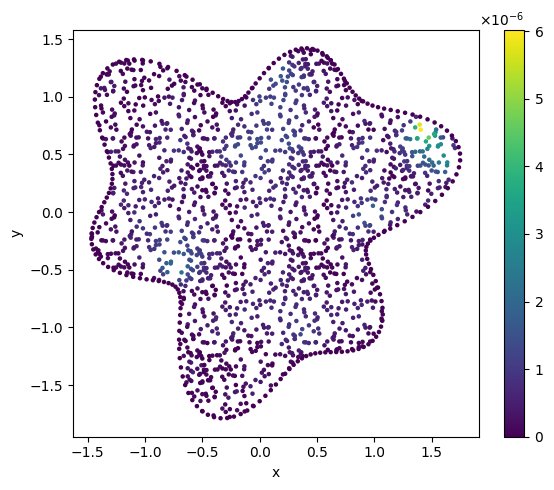

In [35]:
import torch
import time
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat
from scipy.spatial import cKDTree, distance
from scipy.spatial.distance import cdist
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, lsqr
import gc

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()


#############

def r_max_func(theta):
    return 2.0 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))

def inside_star_domain(P):
    """
    P: (N,2)
    判断点是否在极坐标区域 r <= r_max(theta) 内。
    """
    P = np.asarray(P, dtype=np.float64)
    x = P[:, 0]
    y = P[:, 1]
    theta = np.arctan2(y, x)
    theta = np.mod(theta, 2 * np.pi)
    r = np.sqrt(x**2 + y**2)
    rmax = r_max_func(theta)
    return r <= rmax

def estimate_uniform_R_from_target_n_2d(X, target_n, safety=1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    X = np.asarray(X, dtype=np.float64)
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R_2d(X, R, delta=0.2, margin=0.1):
    """
    generate Cartesian patch centers
    2D 中:
        R = (1 + delta) * sqrt(2) * H / 2
        H = 2R / ((1 + delta) sqrt(2))
    """
    X = np.asarray(X, dtype=np.float64)
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(2.0))
    xmin, ymin = X.min(axis=0) - margin
    xmax, ymax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    Xg, Yg = np.meshgrid(gx, gy, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel()]).T
    return C_all, H

def filter_centers_touching_X_2d(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    C_all = np.asarray(C_all, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    keep = np.array(keep, dtype=int)
    return C_all[keep]

def check_patch_cover_and_counts_2d(C, R, X):
    """
    检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    C = np.asarray(C, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_star_2d(X,target_n=100,delta=0.2,safety=1,margin=0.05,max_iter=10):

    X = np.asarray(X, dtype=np.float64)
    # 1. 根据目标 patch 点数估计 R
    R = estimate_uniform_R_from_target_n_2d(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")
        # 2. 根据 R 生成规则中心网格
        C_all, H = generate_centers_from_R_2d(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和区域点集 X 有交集的 centers
        C = filter_centers_touching_X_2d(C_all, X, R)
        # 4. 检查覆盖和 patch 点数
        uncovered, cover_count, nX = check_patch_cover_and_counts_2d(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX & target_n =", nX.mean(),"&", target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，稍微扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info






def laplacian_phi_wrt_y(phi_net, y, X):
    """
    Parameters
    ----------
    y : array-like or tensor, shape (M, 2)
        Evaluation points.
    X : array-like or tensor, shape (K, 2)
        Source points.

    Returns
    -------
    phi_vals : ndarray, shape (M, K)
    lap_y    : ndarray, shape (M, K)
    grad_y   : ndarray, shape (M, K, 2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim() == 1:
        y = y.unsqueeze(0)      # (1, 2)
    M = y.shape[0]
    K = X.shape[0]
    n = y.shape[1]              # dimension (=2)
    # --------------------------------------------------
    # pairwise difference: (M, K, 2)
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]      # (M, K, 2)
    # radial distance: (M, K, 1)
    r = torch.norm(diff, dim=2, keepdim=True) # (M, K, 1)
    r = r.clamp(min=1e-12)
    r.requires_grad_(True)
    # --------------------------------------------------
    # radial basis evaluation
    # --------------------------------------------------
    phi_vals = phi_net(r)       # (M, K, 1)
    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # --------------------------------------------------
    # Laplacian wrt y
    # Δ_y φ = φ''(r) + (n-1)/r φ'(r)
    # --------------------------------------------------
    lap_y = d2phi_dr2 + (n - 1) / r * dphi_dr  # (M, K, 1)
    # --------------------------------------------------
    # Gradient wrt y
    # ∇_y φ = φ'(r) * (y - x) / r
    # --------------------------------------------------
    grad_y = dphi_dr * diff / r                # (M, K, 2)
    # --------------------------------------------------
    # reshape outputs
    # --------------------------------------------------
    phi_vals = phi_vals.squeeze(-1).detach().cpu().numpy()  # (M, K)
    lap_y    = lap_y.squeeze(-1).detach().cpu().numpy()     # (M, K)
    grad_y   = grad_y.detach().cpu().numpy()              # (M, K, 2)
    clear_cuda()
    return phi_vals, lap_y, grad_y

def laplacian_phi_wrt_y_chunked(phi_net,Yj,Xj,chunk_size=800):
    phi_list = []
    grad_list = []
    lap_list = []
    for start in range(0, Yj.shape[0], chunk_size):
        end = min(start + chunk_size, Yj.shape[0])
        y_chunk = Yj[start:end]
        phi, lap, grad = laplacian_phi_wrt_y(phi_net, y_chunk, Xj)
        phi_list.append(phi)
        grad_list.append(grad)
        lap_list.append(lap)
    phi = np.vstack(phi_list)
    grad = np.vstack(grad_list)
    lap = np.vstack(lap_list)
    return phi, lap, grad


def poly2D(Z, order):
    nj = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((nj, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def gradient_poly2D(y,order):
    """
    计算二维多项式基的梯度
    y: M x 2
    return:
        grad_x: Norder x M
        grad_z: Norder x M
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,2)
    M = y.shape[0]
    x = y[:, 0]
    z = y[:, 1]
    Norder = (order + 1) * (order + 2) // 2
    grad_x = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            # 对 x 求导
            if i == 0:
                grad_x[idx, :] = 0.0
            else:
                grad_x[idx, :] = i * (x ** (i - 1)) * (z ** j)
            # 对 z 求导
            if j == 0:
                grad_z[idx, :] = 0.0
            else:
                grad_z[idx, :] = j * (x ** i) * (z ** (j - 1))
            idx += 1
    return grad_x, grad_z

def laplacian_poly2D(y,order):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives(r, diff, R):
    """
    Wendland C2: phi(r) = (4r+1)(1-r)^4, 0 <= r <= 1.

    r:    (M, Nc), scaled distance r = |x-c|/R
    diff: (M, Nc, 2), x[:,None,:] - C[None,:,:]
    R:    (Nc,)
    """
    r = np.asarray(r, dtype=float)
    diff = np.asarray(diff, dtype=float)
    R = np.asarray(R, dtype=float).reshape(-1)

    M, Nc = r.shape
    eps = 1e-14
    mask = (r <= 1.0)

    one_minus = np.maximum(0.0, 1.0 - r)

    # phi'(r) = -20 r (1-r)^3
    # phi''(r) = 20 (1-r)^2 (4r - 1)
    phi_r_prime = -20.0 * r * one_minus**3 * mask
    phi_r_double = 20.0 * one_minus**2 * (4.0 * r - 1.0) * mask

    r_dist = np.linalg.norm(diff, axis=2)
    r_dist_safe = np.maximum(r_dist, eps)

    R_row = R[None, :]
    R2_row = R_row**2

    # grad_x phi = phi'(r) * (x-c)_x / (|x-c| R)
    grad_factor = phi_r_prime / (r_dist_safe * R_row)
    grad_x = grad_factor * diff[:, :, 0]
    grad_y = grad_factor * diff[:, :, 1]

    # 2D Laplacian:
    # Δ_x phi(|x-c|/R) = (phi''(r) + phi'(r)/r) / R^2
    r_safe = np.maximum(r, eps)
    lap = (phi_r_double + phi_r_prime / r_safe) / R2_row

    # at r=0, phi'(r)/r -> -20
    zero_mask = (r_dist < eps) & mask
    lap[zero_mask] = (phi_r_double[zero_mask] - 20.0) / np.broadcast_to(R2_row, r.shape)[zero_mask]

    return grad_x, grad_y, lap


def shepard_weights_with_derivatives(x, ptch_C, ptch_R):
    """
    Return Shepard weights and their x/y gradients and Laplacian.

    x:      (M,2)
    ptch_C: (Nc,2)
    ptch_R: (Nc,)
    """
    x = np.asarray(x, dtype=float)
    ptch_C = np.asarray(ptch_C, dtype=float)
    ptch_R = np.asarray(ptch_R, dtype=float).reshape(-1)

    diff = x[:, None, :] - ptch_C[None, :, :]       # (M,Nc,2)
    r_dist = np.linalg.norm(diff, axis=2)           # (M,Nc)
    r_scaled = r_dist / ptch_R[None, :]             # (M,Nc)

    phi = wendland_C2(r_scaled)                     # (M,Nc)
    phi_x, phi_y, phi_lap = wendland_C2_derivatives(
        r_scaled, diff, ptch_R
    )

    S = np.sum(phi, axis=1, keepdims=True)
    S[S == 0.0] = 1e-12

    Sx = np.sum(phi_x, axis=1, keepdims=True)
    Sy = np.sum(phi_y, axis=1, keepdims=True)
    Slap = np.sum(phi_lap, axis=1, keepdims=True)

    W = phi / S

    Wx = (S * phi_x - phi * Sx) / (S**2)
    Wy = (S * phi_y - phi * Sy) / (S**2)

    # Δ(phi/S)
    lap_W = (
        (S * phi_lap - phi * Slap) / (S**2)
        - 2.0 / S * (Wx * Sx + Wy * Sy)
    )

    return W, Wx, Wy, lap_W

def rfm_fd_pou_poly_solve_nonlinear_poisson(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt):
    """
    X:  (N,2)   source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Np = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    W_matrix, grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2

    scale = True
    # scale = False

    # Construct sparse L matrix
    L = lil_matrix((M1, N))
    Lx = lil_matrix((M1, N))
    Ly = lil_matrix((M1, N))
    LI = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2])
    elif isinstance(f_func, np.ndarray):
        f_val = f_func[:,None] # (M1,1)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2])
    elif isinstance(g_func, np.ndarray):
        g_val = g_func[:,None] # (M2,1)
    else:
        raise ValueError("g_func must be callable or numpy array")
    RHS = np.concatenate([f_val, g_val], axis=0) # (M,1)

    dist_XC = cdist(X, patch_C)      # (N, Nc)
    print("fill_distance of X:", fill_distance(X))
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    start_time = time.time()
    for i in range(Np):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]
        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = Y[idx_Y]
        nj = idx_X.shape[0]
        # print(f"Patch {i+1}/{Np}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")
        AP = np.zeros((nj+Norder,nj+Norder))
        Z = X[idx_X] #(nj,2)
        if scale:
            xc = patch_C[i]
            h_local = patch_R[i]
            Z = (Z - xc[None, :]) / h_local
            Yk = (Yk - xc[None, :]) / h_local
            Yk_in = (Yk_in - xc[None, :]) / h_local

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(nj,-1) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        if Yk.shape[0] * Z.shape[0] >= 2e5:
            phi_YX, lap_phi, grad_phi = laplacian_phi_wrt_y_chunked(Phi, Yk, Z, chunk_size=800)
        else:
            phi_YX, lap_phi, grad_phi = laplacian_phi_wrt_y(Phi, Yk, Z) # (Mk,nj),(Mk,nj,2)
        lap_phi = lap_phi[:Mk_1,:]
        grad_phi_y1, grad_phi_y2 = (grad_phi[:Mk_1,:,0:1].squeeze(-1),grad_phi[:Mk_1,:,1:].squeeze(-1))
        
        if scale:
            lap_phi = lap_phi/ (h_local)**2
            grad_phi_y1 = grad_phi_y1/h_local
            grad_phi_y2 = grad_phi_y2/h_local

        P = poly2D(Z, order) # (nj,Norder)
        AP[:nj,:nj] = Phi_jj
        AP[:nj,nj:] = P
        AP[nj:,:nj] = P.T
        AP = AP + reg * np.eye(nj+Norder) # regularization

        poly_y = poly2D(Yk, order)                   # (Mk,Norder)
        lap_poly_y = laplacian_poly2D(Yk_in, order) # (Norder,Mk_1)
        grad_poly_y1, grad_poly_y2 = gradient_poly2D(Yk_in, order) # (Norder,Mk_1)
        if scale:
            lap_poly_y = lap_poly_y/h_local**2
            grad_poly_y1 = grad_poly_y1/h_local
            grad_poly_y2 = grad_poly_y2/h_local

        RHS_gradx = np.concatenate([grad_phi_y1.T, grad_poly_y1], axis=0) # (nj+Norder,Mk_1)
        RHS_grady = np.concatenate([grad_phi_y2.T, grad_poly_y2], axis=0) # (nj+Norder,Mk_1)
        RHS_ide = np.concatenate([phi_YX.T, poly_y.T], axis=0)    # (nj+Norder,Mk)
        RHS_lap = np.concatenate([lap_phi.T, lap_poly_y], axis=0) # (nj+Norder,Mk_1)
        RHS_all = np.concatenate([RHS_lap,RHS_gradx,RHS_grady,RHS_ide], axis=1) # (K+Norder,4)
        w_all = np.linalg.solve(AP,RHS_all) # (nj+Noder, Mk_1*3 + Mk)
        w_lap = w_all[:nj,:Mk_1]   # 
        w_grad1 = w_all[:nj,Mk_1:Mk_1*2]   # 
        w_grad2 = w_all[:nj,Mk_1*2:Mk_1*3] #
        w_ide = w_all[:nj,Mk_1*3:] # 

        # Shepard weight
        win = W_matrix[idx_Yin, i][None, :]      # (1, Mk_1)
        dx_W = grad_Wx[idx_Yin, i][None, :]    # (1, Mk_1)
        dy_W = grad_Wy[idx_Yin, i][None, :]    # (1, Mk_1)
        d2_W = lap_W[idx_Yin, i][None, :]    # (1, Mk_1)
        # laplace (W * w)
        # Op_in = win * w_lap[:nj, :]
        Op_in = (win * w_lap[:nj, :]+ d2_W * w_ide[:, :Mk_1] + 2.0 * (dx_W * w_grad1 + dy_W * w_grad2))  # (nj, Mk_1)
        L[np.ix_(idx_Yin, idx_X)] += Op_in.T

        # grad (W * w)
        gradx_in = dx_W * w_ide[:, :Mk_1] + win * w_grad1
        grady_in = dy_W * w_ide[:, :Mk_1] + win * w_grad2
        Lx[np.ix_(idx_Yin, idx_X)] += gradx_in.T
        Ly[np.ix_(idx_Yin, idx_X)] += grady_in.T
        # iden
        IDE = W_matrix[idx_Y, i][None, :] * w_ide  # (nj, Mk)
        LI[np.ix_(idx_Y, idx_X)] += IDE.T

    # ===========================================================
    # Solve nonlinear system 
    # - Delta u -u + u^3 = f  in Omega, u = g on boundary
    # ===========================================================
    end_time = time.time()
    print("Time to construct L and LI:", end_time - start_time, "seconds")
    L = L.tocsr()
    LI = LI.tocsr()
    Lx = Lx.tocsr()
    Ly = Ly.tocsr()
    RHS = np.concatenate([10*f_val,g_val],axis=0)
    L1 = scipy.sparse.vstack([L,LI[M1:,:]])

    if M == N:
        alpha = spsolve(L1,RHS)
    else:
        alpha = lsqr(L1, RHS,
            atol= 1e-12,
            btol= 1e-12,
            iter_lim= 2000)[0]
        
    info = {
        "newton_iters": 0,
        "newton_res": [],
        "newton_step": [],
    }
    rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
    alpha = np.asarray(alpha).reshape(-1)
    for iter in range(newton_opt["maxiter"]):
        U = LI[:M1, :] @ alpha
        Ux = Lx @ alpha
        Uy = Ly @ alpha
        LapU = L @ alpha
        F_int = (
            (1.0 + U**2) * LapU
            + 2.0 * U * (Ux**2 + Uy**2)
            - 10.0 * f_val.ravel()
        )
        F_bnd = LI[M1:, :] @ alpha - g_val.ravel()
        F = np.concatenate([F_int, F_bnd])
        res_norm = np.linalg.norm(F) / rhs_norm
        J_int = (
            scipy.sparse.diags(1.0 + U**2) @ L
            + scipy.sparse.diags(2.0 * U * LapU) @ LI[:M1, :]
            + scipy.sparse.diags(2.0 * (Ux**2 + Uy**2)) @ LI[:M1, :]
            + scipy.sparse.diags(4.0 * U * Ux) @ Lx
            + scipy.sparse.diags(4.0 * U * Uy) @ Ly
        )
        J_bnd = LI[M1:, :]
        J = scipy.sparse.vstack([J_int, J_bnd]).tocsr()

        row_max = abs(J).max(axis=1).toarray().ravel()
        row_max[row_max < 1e-14] = 1.0
        scale = 10.0 / row_max
        D = scipy.sparse.diags(scale)
        J_scaled = D @ J
        F_scaled = scale * F
        if J_scaled.shape[0] == J_scaled.shape[1]:
            delta = spsolve(J_scaled, -F_scaled)
        else:
            delta = lsqr(
                J_scaled,
                -F_scaled,
                atol=1e-12,
                btol=1e-12,
                iter_lim=2000)[0]   

        alpha +=   newton_opt["damping"] * delta
        step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

        info["newton_res"].append(res_norm)
        info["newton_step"].append(step_norm)
        print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
        if res_norm < newton_opt["tol"] or step_norm < newton_opt["tol"]:
            break
    # ===========================================================
    # Evaluate solution at Y
    # ===========================================================
    info["newton_iters"] = iter
    info["newton_res"] = np.array(info["newton_res"])
    info["newton_step"] = np.array(info["newton_step"])

    UY = LI.dot(alpha).reshape(-1,1)
    UY[M1:,:] = g_val
    return UY,L,Lx,Ly,LI

# def rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt):
#     """
#     X:  (N,2)   source points
#     Yin: (M1,2) interior points
#     Yb:  (M2,2) boundary points
#     f_func, g_func: Python callable returning torch tensor
#     K: number of neighbors
#     order: 0
#     """
#     # Combine evaluation points
#     patch_C = ptch['C']
#     patch_R = ptch['R']
#     Np = patch_C.shape[0]
#     Y = np.concatenate([Yin, Yb], axis=0)
#     W_matrix = shepard_weights(Y, patch_C, patch_R)  # M x Nc
#     # Compute distance to all source points
#     M = Y.shape[0]
#     N = X.shape[0]
#     M2 = Yb.shape[0] # number of boundary points
#     M1 = M - M2

#     # Construct sparse L matrix
#     L = lil_matrix((M1, N))
#     LI = lil_matrix((M, N))
#     # Construct RHS
#     RHS = np.zeros((M,1))
#     if callable(f_func):
#         f_val = f_func(Yin[:,0:1], Yin[:,1:2])
#     elif isinstance(f_func, np.ndarray):
#         f_val = f_func[:,None] # (M1,1)
#     else:
#         raise ValueError("f_func must be callable or numpy array")
#     if callable(g_func):
#         g_val = g_func(Yb[:,0:1], Yb[:,1:2])
#     elif isinstance(g_func, np.ndarray):
#         g_val = g_func[:,None] # (M2,1)
#     else:
#         raise ValueError("g_func must be callable or numpy array")
#     RHS = np.concatenate([f_val, g_val], axis=0) # (M,1)

#     dist_XC = cdist(X, patch_C)      # (N, Nc)
#     print("fill_distance of X:", fill_distance(X))
#     dist_YC = cdist(Y, patch_C)      # (M, Nc)
#     start_time = time.time()
#     for i in range(Np):
#         idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
#         idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
#         idx_Yin = idx_Y[idx_Y < M1]
#         idx_Yb = idx_Y[idx_Y >= M1]
#         Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
#         Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
#         Yk = Y[idx_Y]
#         nj = idx_X.shape[0]
#         # print(f"Patch {i+1}/{Np}: nj={nj}, Mk={Mk}, Mk_1={Mk_1}")

#         Z = X[idx_X] #(nj,2)
#         h_local = patch_R[i]
#         xc = patch_C[i]
#         Z = (Z - xc[None, :]) / h_local
#         Yk = (Yk - xc[None, :]) / h_local
#         Yk_in = (Yk_in - xc[None, :]) / h_local

#         dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
#         dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
#         Phi_jj = Phi(dist_ZZ).reshape(nj,-1) # (nj,nj)
#         Phi_jj = Phi_jj.detach().cpu().numpy()
#         if Yk.shape[0] * Z.shape[0] >= 2e5:
#             phi_YX, lap_phi, grad_y = laplacian_phi_wrt_y_chunked(Phi, Yk, Z, chunk_size=800)
#         else:
#             phi_YX, lap_phi, _  = laplacian_phi_wrt_y(Phi, Yk, Z) # (Mk,nj)
        
#         lap_phi = lap_phi/ (h_local)**2
#         lap_phi = lap_phi[:Mk_1,:]
#         AP = Phi_jj + reg * np.eye(nj) # regularization

#         RHS_ide = phi_YX.T # (nj,Mk)
#         RHS_lap = lap_phi.T# (nj,Mk_1)
#         RHS_all = np.concatenate([RHS_lap, RHS_ide], axis=1) # (nj,Mk_1 + Mk)
#         w_all = np.linalg.solve(AP,RHS_all) # (nj, Mk_1 + Mk)
#         w_lap = w_all[:,:Mk_1]  # (nj,Mk_1)
#         w_ide = w_all[:, Mk_1:] # (nj,Mk )

#         # Shepard weight
#         win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
#         Op_in =  win * w_lap;          # (nj, Mk_1)
#         L[np.ix_(idx_Yin, idx_X)] +=   Op_in.T
#         # # --- boundary condtion (do not use any more)
#         # wbc = W_matrix[idx_Yb,i][None, :]    # (1, Mk_2)
#         # Op_bc = wbc * w_ide[:,Mk_1:]     # (nj, Mk_2)
#         # L[np.ix_(idx_Yb, idx_X)] = L[np.ix_(idx_Yb, idx_X)] + Op_bc.T
#         # --- Evaluate Matrix for Y
#         wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
#         IDE = wvec * w_ide[:,:]         # (nj,Mk)
#         LI[np.ix_(idx_Y,idx_X)] +=  IDE.T

#     # ===========================================================
#     # Solve nonlinear system 
#     # - Delta u -u + u^3 = f  in Omega, u = g on boundary
#     # ===========================================================
#     end_time = time.time()
#     print("Time to construct L and LI:", end_time - start_time, "seconds")
#     L = L.tocsr()
#     Lx = Lx.tocsr()
#     Ly = Ly.tocsr()
#     LI = LI.tocsr()
#     # take linear poisson solution as inital guess.
#     RHS = np.concatenate([10*f_val,g_val],axis=0)
#     L1 = scipy.sparse.vstack([L,LI[M1:,:]])
#     if M == N:
#         alpha = spsolve(L1,RHS)
#     else:
#         alpha = lsqr(L1, RHS,
#             atol= 1e-12,
#             btol= 1e-12,
#             iter_lim= 2000)[0]
    
#     info = {
#         "newton_iters": 0,
#         "newton_res": [],
#         "newton_step": [],
#     }
#     rhs_norm = np.linalg.norm(np.concatenate([10 * f_val, g_val])) + 1e-14
#     alpha = np.asarray(alpha).reshape(-1)
#     for iter in range(newton_opt["maxiter"]):
#         UY_int = LI[:M1,:] @ alpha  # (M1,)
#         UY_dx = Lx @ alpha
#         UY_dy = Ly @ alpha
#         UY_lap = L @ alpha
        
#         F_int = ((1.0 + UY_int**2) * UY_lap + 2.0 * UY_int * (UY_dx**2 + UY_dy**2) - 10.0 * f_val.flatten()) #(M1,)
#         F_bnd = LI[M1:,:] @ alpha - g_val.flatten()  # (M2,)
#         F = np.concatenate([F_int, F_bnd], axis=0)  # (M,1)
#         res_norm = np.linalg.norm(F) #/ rhs_norm
#         info["newton_res"].append(res_norm)
#         print(f"Newton iter {iter}, relative residual: {res_norm:.2e}")
#         # Jacobian: only interior part
#         J_int = (scipy.sparse.diags(1.0 + UY_int**2) @ L+ scipy.sparse.diags(2.0 * UY_int * UY_lap) @ LI[:M1,:]+ scipy.sparse.diags(2.0 * (UY_dx**2 + UY_dy**2)) @ LI[:M1,:]+ scipy.sparse.diags(4.0 * UY_int * UY_dx) @ Lx+ scipy.sparse.diags(4.0 * UY_int * UY_dy) @ Ly)
#         J_bnd = LI[M1:,:]
#         J = scipy.sparse.vstack([J_int, J_bnd])  # (M,N)
#         if M == N:
#             delta = spsolve(J, -F)  # (M,)
#         else:
#             delta = lsqr(J, -F)[0]  # (M,)
#         alpha +=   newton_opt["damping"] * delta
#         step_norm = np.linalg.norm(delta)/ (np.linalg.norm(alpha) + 1e-14)

#         info["newton_res"].append(res_norm)
#         info["newton_step"].append(step_norm)
#         print(f"Newton {iter}: rel_res = {res_norm:.3e}, rel_step = {step_norm:.3e}")
#         if res_norm < newton_opt["tol"] or step_norm < newton_opt["tol"]:
#             break
#     # ===========================================================
#     # Evaluate solution at Y
#     # ===========================================================
#     info["newton_iters"] = iter
#     info["newton_res"] = np.array(info["newton_res"])
#     info["newton_step"] = np.array(info["newton_step"])

#     UY = LI.dot(alpha).reshape(-1,1)
#     UY[M1:,:] = g_val
#     return UY,L,LI


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = None) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    m.bias.data.zero_()

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 10
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# div((1+u^2) grad u) = 10f
u_func = lambda x, y: x * np.sin(y)
f_func = lambda x, y: (1.0/10.0) * x * np.sin(y) * (-1.0 + 2.0*np.sin(y)**2 + x**2 * (2.0*np.cos(y)**2 - np.sin(y)**2))
g_func = lambda x, y: u_func(x,y)


torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
print("X.shape:", X.shape)
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
reg = 1e-14
order = 3
u_true = u_func(Y[:,0:1], Y[:,1:2])

C, R, info = generate_patches_star_2d(X,target_n=100,delta=0.2,safety=1.25,margin=0.05,max_iter=10)
ptch = {
    "C": C,
    "R": R
}

newton_opt={"maxiter": 20, "tol": 1e-13, "damping": 1.0}
# # ===========================================================
if order == 0:
    UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
else:
    UY,L,Lx,Ly,LI= rfm_fd_pou_poly_solve_nonlinear_poisson(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

# print(u_true.shape,UY.shape)
error = np.abs(UY - u_true)#/np.abs(u_true + 1e-6)
# print(error)
# if global_error_vmax <= error.max().item():
#     global_error_vmax = error.max().item()
print(f'L infity error in u: {error.max().item():.3e}')
error_u = np.linalg.norm(UY - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'Relative L2 error in u: {error_u.item():.3e}')

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5,)
# sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UY - u_true), cmap='viridis', s=5, vmin=global_error_vmin,
#     vmax=global_error_vmax)
cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.savefig(f'./result/nonlinear_poisson_rfmfd_pou_p={order}_error_sincos.eps', bbox_inches='tight')
plt.show()

##

In [ ]:
key = 100
np.random.seed(key)
H = np.zeros((4,5))
E = np.zeros((4,5))
NN = [20,40,70,130,200]
KK = [20,40,70,140,220]
RR = [1e-7,1e-12,1e-13,1e-14,1e-15]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    K = KK[qi]

    C, R, info = generate_patches_star_2d(X,target_n=K,delta=0.2,safety=1.25,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }
    if order == 0:
        UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
    else:
        UY,_,_= rfm_fd_pou_poly_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig('./result/p=0_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()




Run Q=1, N_local_per_patch=20
X.shape 183

--- iter 0 ---
========== Patch report ==========
num patches: 24
R = 0.6454506405769556
uncovered X: 0 / 183
cover count min/mean/max: 1 2.26775956284153 4
patch nX min/mean/max: 1 17.291666666666668 35
H = 0.7606708747886104
target_n = 20
mean nX & target_n = 17.291666666666668 & 20
fill_distance of X: 0.2631459102593757


Time to construct L and LI: 1.105053424835205 seconds


UnboundLocalError: cannot access local variable 'Lx' where it is not associated with a value

In [33]:
# key = 100
# np.random.seed(key)

# # NN = [20]
# # KK = [20]
# # RR = [1e-10]

# # NN = [40]
# # KK = [40]
# # RR = [1e-12]

# # NN = [70]
# # KK = [70]
# # RR = [1e-13]

# NN = [130]
# KK = [200]
# RR = [1e-13]

# # NN = [200]
# # KK = [300]
# # RR = [1e-13]

# newton_opt={"maxiter": 20, "tol": 1e-13, "damping": 1.0}

# for qi, n_local in enumerate(NN):
#     print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
#     N_patch_grid = 5
#     N_local_per_patch = n_local
#     N_boundary = n_local
#     R_ptch = 0.8
#     mode = "c-rbf-pum"
#     # generate points
#     X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
#     N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
#     # assemble X,Y
#     X = np.vstack([X_inner, X_boundary])
#     print(f"X.shape",X.shape[0])
#     Yin = X_inner
#     Yb = X_boundary
#     Y = np.vstack([Yin, Yb])
#     order = 1
#     h = fill_distance(X)
#     reg = RR[qi]
#     u_true = u_func(Y[:,0:1], Y[:,1:2])
#     K = KK[qi]

#     C, R, info = generate_patches_star_2d(X,target_n=K,delta=0.25,safety=1.25,margin=0.05,max_iter=10)
#     ptch = {
#         "C": C,
#         "R": R
#     }
#     if order == 0:
#         UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
#     else:
#         UY,_,_= rfm_fd_pou_poly_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

#     error = np.max(np.abs(UY - u_true))
#     e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
#     print(f'h = {h:.3e}, L2 error = {e:.3e}')



Run Q=1, N_local_per_patch=20
X.shape 183

--- iter 0 ---
========== Patch report ==========
num patches: 24
R = 0.6454506405769556
uncovered X: 0 / 183
cover count min/mean/max: 1 2.26775956284153 4
patch nX min/mean/max: 1 17.291666666666668 35
H = 0.7606708747886104
target_n = 20
mean nX & target_n = 17.291666666666668 & 20
fill_distance of X: 0.2631459102593757
Time to construct L and LI: 1.1280150413513184 seconds
Newton iter 0, relative residual: 1.14e+02
Newton 0: rel_res = 1.138e+02, rel_step = 9.332e-01
Newton iter 1, relative residual: 3.89e-01
Newton 1: rel_res = 3.886e-01, rel_step = 4.522e-02
Newton iter 2, relative residual: 2.86e-03
Newton 2: rel_res = 2.862e-03, rel_step = 3.999e-04
Newton iter 3, relative residual: 2.32e-07
Newton 3: rel_res = 2.318e-07, rel_step = 3.458e-08
Newton iter 4, relative residual: 8.46e-14
Newton 4: rel_res = 8.463e-14, rel_step = 3.092e-13
h = 2.631e-01, L2 error = 1.256e-01
Run Q=2, N_local_per_patch=40
X.shape 366

--- iter 0 ---
========

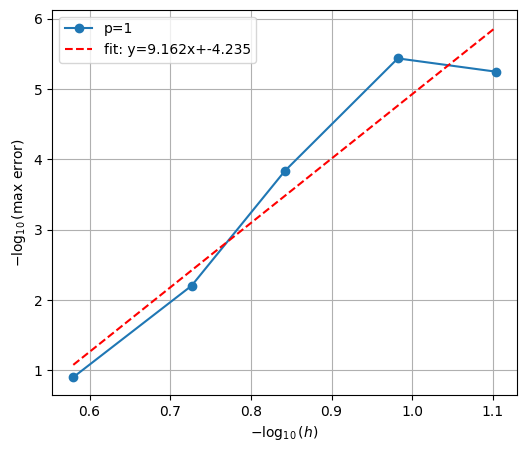

In [7]:
key = 100
np.random.seed(key)
NN = [20,40,70,130,200]
KK = [20,40,70,140,220]
RR = [1e-8,1e-13,1e-13,1e-15,1e-14]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    K = KK[qi]
    C, R, info = generate_patches_star_2d(X,target_n=K,delta=0.2,safety=1.25,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }
    if order == 0:
        UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
    else:
        UY,_,_= rfm_fd_pou_poly_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig('./result/p=0_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()




Run Q=1, N_local_per_patch=20
X.shape 183

--- iter 0 ---
========== Patch report ==========
num patches: 24
R = 0.6454506405769556
uncovered X: 0 / 183
cover count min/mean/max: 1 2.26775956284153 4
patch nX min/mean/max: 1 17.291666666666668 35
H = 0.7606708747886104
target_n = 20
mean nX & target_n = 17.291666666666668 & 20
fill_distance of X: 0.2631459102593757
Time to construct L and LI: 1.2252564430236816 seconds
Newton iter 0, relative residual: 1.09e+02
Newton 0: rel_res = 1.090e+02, rel_step = 9.350e-01
Newton iter 1, relative residual: 4.19e-01
Newton 1: rel_res = 4.187e-01, rel_step = 4.914e-02
Newton iter 2, relative residual: 3.18e-03
Newton 2: rel_res = 3.183e-03, rel_step = 4.685e-04
Newton iter 3, relative residual: 3.14e-07
Newton 3: rel_res = 3.141e-07, rel_step = 5.815e-08
Newton iter 4, relative residual: 1.29e-13
Newton 4: rel_res = 1.292e-13, rel_step = 1.884e-12
Newton iter 5, relative residual: 1.14e-13
Newton 5: rel_res = 1.141e-13, rel_step = 1.386e-12
Newton 

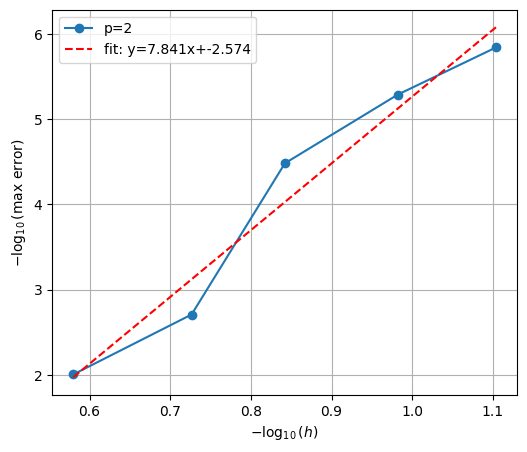

In [8]:
key = 100
np.random.seed(key)
NN = [20,40,70,130,200]
KK = [20,40,70,140,200]
RR = [1e-8,1e-13,1e-13,1e-14,1e-15]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    K = KK[qi]
    C, R, info = generate_patches_star_2d(X,target_n=K,delta=0.2,safety=1.25,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }
    if order == 0:
        UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
    else:
        UY,_,_= rfm_fd_pou_poly_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig('./result/p=0_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=20
X.shape 183

--- iter 0 ---
========== Patch report ==========
num patches: 22
R = 0.6712686662000338
uncovered X: 0 / 183
cover count min/mean/max: 1 2.300546448087432 4
patch nX min/mean/max: 1 19.136363636363637 40
H = 0.7910977097801548
target_n = 20
mean nX & target_n = 19.136363636363637 & 20
fill_distance of X: 0.2631459102593757
Time to construct L and LI: 1.0019757747650146 seconds
Newton iter 0, relative residual: 1.21e+02
Newton 0: rel_res = 1.212e+02, rel_step = 9.388e-01
Newton iter 1, relative residual: 4.57e-01
Newton 1: rel_res = 4.572e-01, rel_step = 7.326e-02
Newton iter 2, relative residual: 7.73e-03
Newton 2: rel_res = 7.726e-03, rel_step = 7.052e-03
Newton iter 3, relative residual: 9.33e-05
Newton 3: rel_res = 9.331e-05, rel_step = 8.499e-05
Newton iter 4, relative residual: 2.79e-08
Newton 4: rel_res = 2.794e-08, rel_step = 1.802e-08
Newton iter 5, relative residual: 1.76e-13
Newton 5: rel_res = 1.755e-13, rel_step = 5.027e-13
Newton

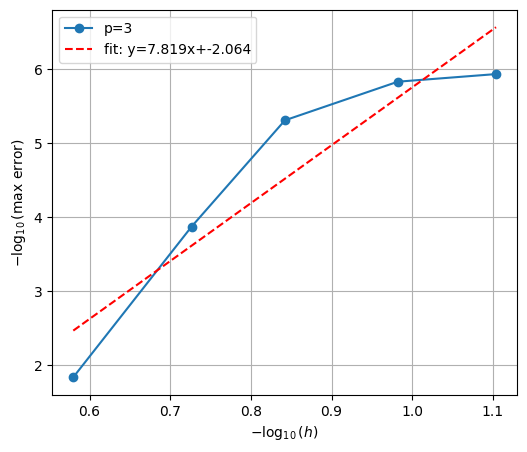

In [8]:
key = 100
np.random.seed(key)
NN = [20,40,70,130,200]
KK = [20,40,70,130,200]
RR = [1e-8,1e-12,1e-13,1e-13,1e-13]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    print(f"X.shape",X.shape[0])
    Yin = X_inner
    Yb = X_boundary
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2])
    K = KK[qi]
    C, R, info = generate_patches_star_2d(X,target_n=K,delta=0.2,safety=1.3,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }
    if order == 0:
        UY,_,_ = rfm_fd_pou_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, newton_opt)
    else:
        UY,_,_= rfm_fd_pou_poly_solve_Allen_Cahn(ptch, X, Yin, Yb, f_func, g_func, Phi, reg, order, newton_opt)

    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true)/np.linalg.norm(u_true)
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig('./result/p=0_convergence_scatter_xcos.eps', bbox_inches='tight')
    plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


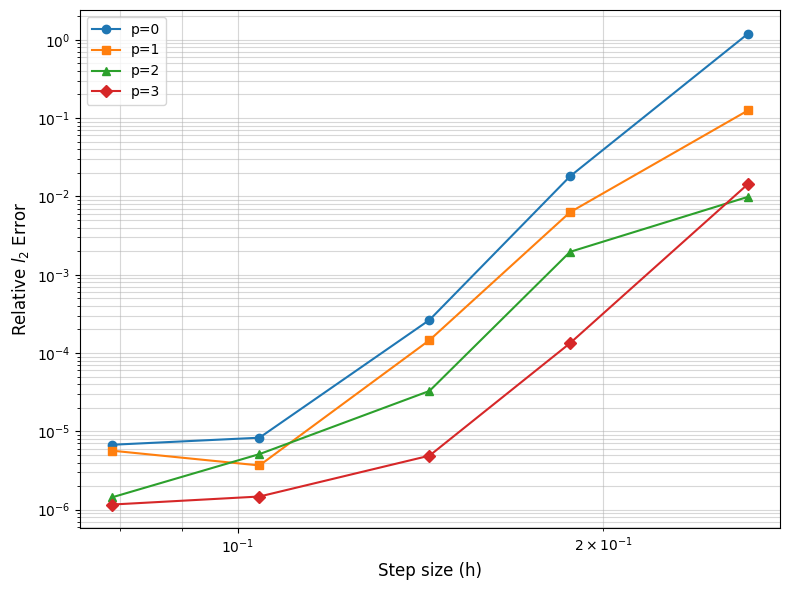

In [ ]:
markers = ['o', 's', '^', 'D', ]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',]
labels = ['p=0', 'p=1', 'p=2', 'p=3',]

plt.figure(figsize=(8, 6))
for i in range(4):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, '-' + markers[i], color=colors[i], label=f'{labels[i]}')
    # plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)


# h = np.array([0.226473316206159,0.117514159784914,0.0640581633226791,])
# e = np.array([0.000565997277071441,0.000143535417042626,3.62243806175985e-05,])
# log_h = np.log(h)
# log_e = np.log(e)
# slope, intercept = np.polyfit(log_h, log_e, 1)
# fit_e = np.exp(intercept) * h**slope
# plt.loglog(h, e, markers[4], color=colors[4], label=f'{labels[4]}')
# plt.loglog(h, fit_e, linestyle='--', color=colors[4], alpha=0.7)

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('./result/nonlinear_poisson_rfmfd_pou_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()